# Práctica adicional 10b — k-NN de regresión sobre un problema de estructura no lineal

Las notas de la clase muestran que la versión de regresión de k-NN cambia **una sola línea**
del algoritmo: donde la clasificación vota, la regresión promedia,

$$
\hat f(\mathbf{x}_0) \;=\; \frac{1}{k}\sum_{i \in \mathcal{N}_k(\mathbf{x}_0)} y_i ,
$$

sobre el mismo vecindario y con la misma métrica. El laboratorio de la clase no la
implementa por esa razón. Lo que sí cambia por completo es **con qué se compara**: la línea
base deja de ser la regresión logística y pasa a ser el modelo lineal de la clase 3.

Esta práctica ajusta un k-NN de regresión sobre el conjunto `Auto`, donde la relación entre
los atributos y la respuesta **es visiblemente curva**, y lo enfrenta a esa línea base. La
pregunta es doble: cuánto gana un método local cuando el modelo lineal está mal
especificado, y **de dónde sale exactamente lo que gana**.

Por el camino aparece un atributo categórico disfrazado de número, que es el segundo tema
de la práctica: el origen del vehículo viene codificado como $1$, $2$ y $3$, y esos números
entran en la distancia si nadie los detiene.

Hay **tres ejercicios**. Las celdas que contienen `raise NotImplementedError()` deben
completarse; el resto es andamiaje y se ejecuta sin modificar. La conclusión final la
escribe el estudiante: el entregable de esta práctica es esa conclusión, justificada con
las cifras que las celdas producen.

> **Notación.** $\hat f$ el predictor, $k$ el tamaño del vecindario,
> $\mathcal{N}_k(\mathbf{x}_0)$ el conjunto de índices de los $k$ vecinos de
> $\mathbf{x}_0$, $\pi_j$ la proporción del nivel $j$ de un atributo categórico y $m$ su
> cantidad de niveles. El error se mide con la raíz del error cuadrático medio,
> $\operatorname{RECM} = \bigl(n^{-1}\sum_i (y_i-\hat f(\mathbf{x}_i))^2\bigr)^{1/2}$, en
> las unidades de la respuesta.

## 0. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

# Paleta del curso
AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

SEMILLA = 42


def recm(y_verdadero: np.ndarray, y_predicho: np.ndarray) -> float:
    """Raíz del error cuadrático medio, en las unidades de la respuesta."""
    return float(np.sqrt(mean_squared_error(y_verdadero, y_predicho)))

In [2]:
from pathlib import Path
import urllib.request

# Carga de datos del curso. No hace falta modificar nada.
URL_DATOS = "https://raw.githubusercontent.com/gustavovazquez/datasets/main/"


def ruta_del_dato(nombre: str) -> str:
    """Devuelve algo que `pd.read_csv` pueda leer, este donde este el notebook.

    Busca el archivo junto al notebook y en las carpetas `data/` de hasta tres
    niveles superiores; si no esta, usa la copia publicada en linea; y si
    tampoco hay red, en Colab ofrece subirlo a mano.
    """
    candidatas = [Path(nombre), Path("data") / nombre]
    for arriba in ("..", "../..", "../../.."):
        candidatas += [Path(arriba) / nombre, Path(arriba) / "data" / nombre]
    for ruta in candidatas:
        if ruta.exists():
            print(f"Cargado desde {ruta}")
            return str(ruta)

    url = URL_DATOS + nombre
    try:
        urllib.request.urlopen(url, timeout=15)
        print(f"No esta en disco; se descarga de {url}")
        return url
    except Exception:
        pass

    try:
        from google.colab import files  # type: ignore
    except ImportError:
        raise FileNotFoundError(
            f"No se encontro {nombre}. Dejarlo en una carpeta 'data/' junto al notebook.")

    print(f"Falta {nombre}: seleccionar el archivo para subirlo.")
    subidos = files.upload()
    destino = Path("data")
    destino.mkdir(exist_ok=True)
    ruta = destino / nombre
    ruta.write_bytes(subidos[nombre])
    return str(ruta)

### Los datos

`auto_islp.csv`, $392 \times 9$: el conjunto `Auto` de ISLP, con el consumo de $392$
automóviles fabricados entre $1970$ y $1982$. La respuesta es `mpg`, millas por galón, de
modo que **un valor alto es un vehículo eficiente**.

| Columna | Tipo | Qué es |
|---|---|---|
| `mpg` | respuesta numérica | Millas por galón |
| `cylinders` | recuento, $\{3,4,5,6,8\}$ | Cantidad de cilindros |
| `displacement`, `horsepower`, `weight`, `acceleration` | numéricos | Cilindrada, potencia, peso y aceleración |
| `year` | numérico | Año de modelo, $70$ a $82$ |
| `origin` | **categórico codificado como entero** | $1$ Estados Unidos, $2$ Europa, $3$ Japón |
| `name` | texto | Marca y modelo. $301$ valores distintos en $392$ filas |

El conjunto **no tiene faltantes** y no necesita más tratamiento previo que el escalado.
Dos columnas requieren una decisión antes de entrar en una distancia, y las dos se tratan
en la sección 1.

> **Antes de ejecutar.** El archivo se descarga de webasignatura y corresponde dejarlo en
> una carpeta `data/` junto al notebook. En Colab, si el archivo no está, la celda de carga
> ofrece subirlo.

Cargado desde data/auto_islp.csv
conjunto completo : 392 vehículos, 7 atributos
entrenamiento     : 294   mpg medio 23.6922
prueba            : 98   mpg medio 22.7071
faltantes         : 0
valores distintos de 'name' : 301 en 392 filas

origen:
origin
EEUU      0.6250
Japon     0.2015
Europa    0.1735

escalas de los atributos numéricos:
                 mean     std
cylinders        5.47    1.71
displacement   194.41  104.64
horsepower     104.47   38.49
weight        2977.58  849.40
acceleration    15.54    2.76
year            75.98    3.68


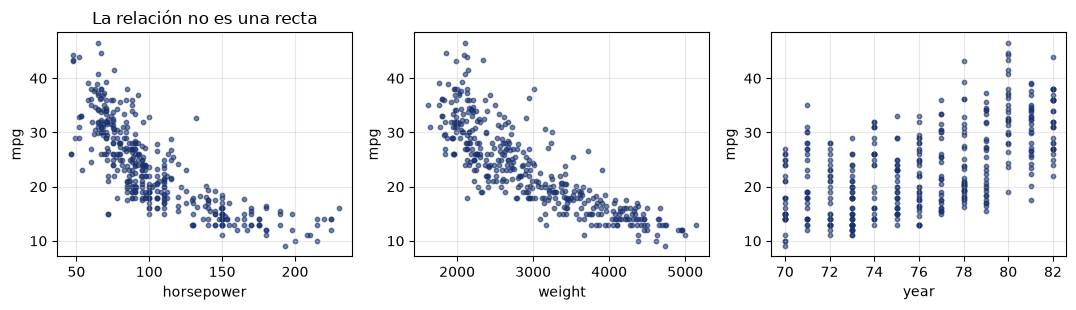

In [3]:
auto = pd.read_csv(ruta_del_dato("auto_islp.csv"))

RESPUESTA = "mpg"
ORIGENES = {1: "EEUU", 2: "Europa", 3: "Japon"}

y = auto[RESPUESTA].to_numpy(dtype=float)
X = auto.drop(columns=[RESPUESTA, "name"]).copy()
X["origin"] = X["origin"].map(ORIGENES)

X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.25, random_state=SEMILLA)

print(f"conjunto completo : {len(auto)} vehículos, {X.shape[1]} atributos")
print(f"entrenamiento     : {len(y_ent)}   mpg medio {y_ent.mean():.4f}")
print(f"prueba            : {len(y_pru)}   mpg medio {y_pru.mean():.4f}")
print(f"faltantes         : {int(auto.isna().sum().sum())}")
print(f"valores distintos de 'name' : {auto['name'].nunique()} en {len(auto)} filas")
print()
print("origen:")
print(X["origin"].value_counts(normalize=True).round(4).to_string())
print()
print("escalas de los atributos numéricos:")
print(X.select_dtypes("number").agg(["mean", "std"]).T.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, ["horsepower", "weight", "year"]):
    ax.scatter(auto[col], auto["mpg"], s=10, c=AZUL, alpha=0.6)
    ax.set_xlabel(col); ax.set_ylabel("mpg")
axes[0].set_title("La relación no es una recta")
plt.tight_layout(); plt.show()

---

# 1. Dos columnas que no entran tal como vienen

## `name`: alta cardinalidad, y por qué se descarta

`name` tiene $301$ valores distintos en $392$ filas. Codificarlo con indicadoras agregaría
$301$ columnas y, sobre todo, **dejaría de distinguir**: dos vehículos cualesquiera casi
siempre difieren de nombre, de modo que el aporte del atributo a la distancia al cuadrado
sería $2$ para casi todo par. Un término constante en la distancia no ordena a nadie: no
cambia quiénes son los vecinos y solo agrega dimensión. La columna se descarta, y ya quedó
descartada en la celda anterior.

Ese es el caso extremo de una regla general: **en una distancia, un atributo categórico
informa en la medida en que sus niveles agrupan**. Con muchos niveles y pocas
observaciones por nivel, no agrupa.

## `origin`: un entero que no es un número

`origin` vale $1$, $2$ o $3$, y esos números son **etiquetas**: Estados Unidos, Europa,
Japón. Si la columna entra en la distancia tal como viene, estandarizada como cualquier
otra, el aporte del origen a la distancia al cuadrado entre dos vehículos queda fijado por
la aritmética de las etiquetas.

La codificación indicadora reemplaza la columna por $m$ columnas $0/1$, una por nivel, con
un único $1$ por fila. Su aporte a la distancia al cuadrado entre dos observaciones vale

$$
\sum_{j=1}^{m}\bigl(x_{aj}-x_{bj}\bigr)^{2}
=\begin{cases}
0, & \text{si comparten nivel},\\[2pt]
2, & \text{si no},
\end{cases}
$$

porque dos filas de nivel distinto difieren en exactamente dos columnas, en una unidad cada
una: **todos los pares de niveles distintos quedan a la misma distancia**, que es lo que
significa que un atributo sea nominal. Tres precisiones, propias de k-NN:

- **No se descarta ningún nivel.** En un modelo lineal se elimina una columna
  (`drop="first"`) para evitar la colinealidad perfecta con el intercepto; en una distancia
  eso deja al nivel de referencia a distancia al cuadrado $1$ de los demás mientras los
  demás quedan a $2$ entre sí, y lo vuelve artificialmente el más parecido a todo. Con dos
  niveles no hay problema: una sola columna $0/1$ ya es simétrica.
- **Estandarizar las indicadoras no es neutral.** Una indicadora de proporción $\pi_j$ tiene
  varianza $\pi_j(1-\pi_j)$; al estandarizarla, el aporte de un nivel poco frecuente crece.
  Es una decisión de ponderación, y conviene tomarla a la vista de la cuenta.
- **El aporte se mide.** Del laboratorio de la clase,
  $\mathbb{E}[(X_j-X'_j)^2]=2\operatorname{Var}(X_j)$, de modo que un atributo numérico
  estandarizado aporta exactamente $2$. Esa es la vara para comparar codificaciones.

La celda siguiente hace las dos cuentas sobre `origin` antes de decidir nada.

In [4]:
# Qué afirma cada codificación sobre las distancias entre orígenes
codigo = auto["origin"].to_numpy(dtype=float)
z = (codigo - codigo.mean()) / codigo.std()
valores = {ORIGENES[int(c)]: v for c, v in zip(codigo, z)}

print("Codificación como entero 1/2/3, estandarizada:")
for nombre, valor in valores.items():
    print(f"  {nombre:8s} -> {valor:7.4f}")
print("  aporte a la distancia al cuadrado entre pares de orígenes:")
for a in valores:
    for b in valores:
        if a < b:
            print(f"    {a:8s} contra {b:8s} : {(valores[a] - valores[b]) ** 2:6.4f}")

print("\nCodificación indicadora, sin estandarizar:")
print("  aporte entre dos orígenes distintos : 2.0000, para todo par")
print("  aporte entre dos vehículos del mismo origen : 0.0000")

pi = auto["origin"].value_counts(normalize=True)
print(f"\nAporte total del atributo a E[d^2], contra el 2.0000 de una columna estandarizada:")
print(f"  entero 1/2/3 estandarizado    : {2 * z.var():.4f}")
print(f"  indicadoras sin estandarizar  : {2 * (1 - (pi ** 2).sum()):.4f}")
print(f"  indicadoras estandarizadas    : {2 * len(pi):.4f}")

Codificación como entero 1/2/3, estandarizada:
  EEUU     -> -0.7166
  Japon    ->  1.7694
  Europa   ->  0.5264
  aporte a la distancia al cuadrado entre pares de orígenes:
    EEUU     contra Japon    : 6.1804
    EEUU     contra Europa   : 1.5451
    Europa   contra Japon    : 1.5451

Codificación indicadora, sin estandarizar:
  aporte entre dos orígenes distintos : 2.0000, para todo par
  aporte entre dos vehículos del mismo origen : 0.0000

Aporte total del atributo a E[d^2], contra el 2.0000 de una columna estandarizada:
  entero 1/2/3 estandarizado    : 2.0000
  indicadoras sin estandarizar  : 1.0773
  indicadoras estandarizadas    : 6.0000


### DECIDE

`cylinders` toma los valores $\{3,4,5,6,8\}$ y admite las dos lecturas: es un **recuento**,
con un orden y un espaciamiento que significan algo, y es también una **etiqueta** de
familia de motor, con cinco niveles muy desparejos.

**¿Corresponde tratar `cylinders` como atributo numérico o como categórico?** La respuesta
tiene que decir qué afirma cada opción sobre la distancia entre un motor de $4$ cilindros y
uno de $8$, y cuánto aportaría el atributo en cada caso.

**Respuesta:** 
Trataría `cylinders` como numérico porque es un recuento físico cuyo
orden y diferencias tienen significado. Estandarizado, pasar de 4 a 8 cilindros
aporta $(8-4)^2/s^2$ a la distancia al cuadrado; con estos datos, aproximadamente
$5.47$. Si se tratara como categórico, cualquier par de cantidades diferentes
aportaría siempre $2$, de modo que 4 y 8 quedarían tan separados como 4 y 5. La
opción categórica sería preferible solamente si se interpreta cada cantidad como
una familia de motor sin distancia ordinal fiable.

## Cómo se hace en `scikit-learn`

Las decisiones anteriores no se programan a mano: se expresan como argumentos de la
biblioteca. Y en este conjunto hay además **una trampa previa a todas ellas**.

### La trampa: `origin` llega como entero

`origin` viene en el archivo con `dtype` entero, y **ninguna herramienta que seleccione
columnas por tipo de dato lo va a reconocer como categórico**. Ni `select_dtypes("number")`,
que lo incluye entre los numéricos, ni `make_column_selector(dtype_include=object)`, que lo
deja afuera de los categóricos. Las dos hacen exactamente lo que dice su nombre, y el
resultado es un `ColumnTransformer` que estandariza el código $1/2/3$ **sin una sola
advertencia**.

La celda de carga de este notebook lo evitó traduciendo los códigos a etiquetas antes de
partir el conjunto. Es la práctica que conviene adoptar: **traducir los códigos apenas se
leen los datos**, para que el tipo de dato coincida con la naturaleza del atributo. La
alternativa —nombrar las columnas de cada bloque explícitamente, sin selección automática—
también funciona, y es más segura cuando los atributos son pocos.

### `OneHotEncoder` — la codificación indicadora

| Argumento | Valor | Qué hace, y qué significa acá |
|---|---|---|
| `drop` | `None` (predeterminado) | Una columna por nivel. **Es el valor que corresponde en k-NN**: deja simétricos todos los pares de niveles, con aporte $2$ |
| | `"first"` | Descarta el primer nivel. Es lo obligatorio en un modelo lineal, para evitar la colinealidad con el intercepto, y lo que rompe la simetría de la distancia |
| | `"if_binary"` | Descarta un nivel solo cuando el atributo tiene dos. Inocuo en una distancia |
| `sparse_output` | `False` | Devuelve un `ndarray` denso en vez de una matriz rala, que se puede imprimir e inspeccionar |
| `handle_unknown` | `"ignore"` | Un nivel no visto al ajustar produce una fila de ceros en lugar de un error. Con validación cruzada y niveles poco frecuentes, evita que una partición falle |
| `min_frequency`, `max_categories` | enteros | Agrupan los niveles raros en `infrequent_sklearn`. Es la herramienta para la alta cardinalidad de `name` |

El codificador acepta columnas numéricas sin protestar: **que `origin` sea entero no impide
codificarlo**, lo único que hace falta es no dejar que la selección por tipo lo desvíe.
Después de ajustar, `codificador.categories_` da el orden de los niveles y
`get_feature_names_out()`, los nombres de las columnas.

> **`OrdinalEncoder` no es la alternativa.** Produce exactamente el código entero
> $0,1,2,\dots$ del que se viene hablando. Es la herramienta correcta para un atributo
> genuinamente ordinal cuyo espaciamiento se quiera afirmar, y la incorrecta para uno
> nominal como el origen.

### `ColumnTransformer` y `Pipeline`

`ColumnTransformer` aplica un transformador distinto a cada bloque de columnas y concatena
el resultado; se construye con tripletas `(nombre, transformador, columnas)`. Su valor
predeterminado `remainder="drop"` **descarta sin aviso toda columna que no figure en ninguna
tripleta**: cómodo y peligroso en la misma medida, y por eso la verificación del ejercicio
cuenta las columnas de salida.

`Pipeline` encadena ese transformador con el modelo, de modo que ambos se ajusten **una vez
por partición** de la validación cruzada y con los datos de entrenamiento de esa partición
solamente. En k-NN eso es lo que evita que el conjunto de validación participe de definir
quiénes son vecinos.

Las dos celdas siguientes muestran la trampa y el codificador aislado, sobre una tabla
mínima donde cada cuenta se puede seguir a mano.

In [5]:
# La trampa, sobre el archivo tal como se lee, antes de traducir los códigos
crudo = pd.read_csv(ruta_del_dato("auto_islp.csv")).drop(columns=["mpg", "name"])
print("dtypes tal como llegan:")
print(crudo.dtypes.to_string())
print()
print("select_dtypes('number') incluye :", list(crudo.select_dtypes("number").columns))
print("make_column_selector(object)    :", make_column_selector(dtype_include=object)(crudo))
print()
print("origin queda del lado numérico y se estandariza como si fuera una magnitud.")
print("La celda de carga lo evitó traduciendo los códigos a etiquetas:")
print("  dtype de origin después de traducir :", X["origin"].dtype)
print("  categóricos detectados              :",
      make_column_selector(dtype_include=object)(X))

Cargado desde data/auto_islp.csv
dtypes tal como llegan:
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
year              int64
origin            int64

select_dtypes('number') incluye : ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
make_column_selector(object)    : []

origin queda del lado numérico y se estandariza como si fuera una magnitud.
La celda de carga lo evitó traduciendo los códigos a etiquetas:
  dtype de origin después de traducir : str
  categóricos detectados              : ['origin']


In [6]:
# El codificador aislado, sobre una tabla mínima
juguete = pd.DataFrame({"origen": ["EEUU", "Europa", "Japon", "EEUU"]})


def distancias_al_cuadrado(Z: np.ndarray) -> np.ndarray:
    """Matriz de distancias al cuadrado entre todas las filas de Z."""
    return ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(axis=2)


variantes_juguete = [
    ("drop=None — una columna por nivel",
     OneHotEncoder(sparse_output=False)),
    ("drop=\"first\" — el primer nivel se descarta",
     OneHotEncoder(drop="first", sparse_output=False)),
    ("drop=None, con las indicadoras estandarizadas",
     Pipeline([("ohe", OneHotEncoder(sparse_output=False)), ("esc", StandardScaler())])),
]

etiquetas = juguete["origen"].to_numpy()
for titulo, transformador in variantes_juguete:
    Z = transformador.fit_transform(juguete)
    columnas = [c.replace("origen_", "") for c in transformador.get_feature_names_out()]
    print(f"--- {titulo} ---")
    print(pd.DataFrame(Z, index=etiquetas, columns=columnas).round(3).to_string())
    print("distancias al cuadrado entre las cuatro filas:")
    print(pd.DataFrame(distancias_al_cuadrado(Z),
                       index=etiquetas, columns=etiquetas).round(3).to_string())
    print()

print("Con drop=None todo par de orígenes distintos vale 2 y todo par igual vale 0.")
print("Con drop=\"first\", 'EEUU' queda a 1 de los otros dos y esos dos a 2 entre sí:")
print("el nivel descartado se vuelve el más parecido a todo.")

# Un nivel no visto al ajustar, y el agrupamiento de niveles raros
codificador = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(juguete)
print("\ncategories_:", codificador.categories_)
print("un origen no visto, 'Corea', se codifica como",
      codificador.transform(pd.DataFrame({"origen": ["Corea"]}))[0],
      "\n  (con handle_unknown='error', el valor predeterminado, sería una excepción)")

nombres = pd.DataFrame({"name": pd.read_csv(ruta_del_dato("auto_islp.csv"))["name"]})
agrupador = OneHotEncoder(sparse_output=False, min_frequency=5).fit(nombres)
print(f"\nmin_frequency=5 sobre 'name': {nombres['name'].nunique()} niveles distintos "
      f"quedan en {len(agrupador.get_feature_names_out())} columnas")
print("  aun así se descarta la columna: agrupar no la vuelve informativa")

--- drop=None — una columna por nivel ---
        EEUU  Europa  Japon
EEUU     1.0     0.0    0.0
Europa   0.0     1.0    0.0
Japon    0.0     0.0    1.0
EEUU     1.0     0.0    0.0
distancias al cuadrado entre las cuatro filas:
        EEUU  Europa  Japon  EEUU
EEUU     0.0     2.0    2.0   0.0
Europa   2.0     0.0    2.0   2.0
Japon    2.0     2.0    0.0   2.0
EEUU     0.0     2.0    2.0   0.0

--- drop="first" — el primer nivel se descarta ---
        Europa  Japon
EEUU       0.0    0.0
Europa     1.0    0.0
Japon      0.0    1.0
EEUU       0.0    0.0
distancias al cuadrado entre las cuatro filas:
        EEUU  Europa  Japon  EEUU
EEUU     0.0     1.0    1.0   0.0
Europa   1.0     0.0    2.0   1.0
Japon    1.0     2.0    0.0   1.0
EEUU     0.0     1.0    1.0   0.0

--- drop=None, con las indicadoras estandarizadas ---
        EEUU  Europa  Japon
EEUU     1.0  -0.577 -0.577
Europa  -1.0   1.732 -0.577
Japon   -1.0  -0.577  1.732
EEUU     1.0  -0.577 -0.577
distancias al cuadrado entr

### Ejercicio 1 — La preparación

Corresponde construir el `ColumnTransformer` que lleva el `DataFrame` a la matriz sobre la
que se mide la distancia: los atributos numéricos estandarizados, y el categórico con una
indicadora por nivel, **sin descartar ninguna y sin estandarizarlas**.

La función devuelve el transformador **sin ajustar**: quien lo ajusta es el `Pipeline`, y
solo con los datos de entrenamiento de cada partición.

In [7]:
def preparacion(datos: pd.DataFrame) -> ColumnTransformer:
    numericos = [
        c for c in datos.columns
        if pd.api.types.is_numeric_dtype(datos[c])
    ]
    categoricos = [c for c in datos.columns if c not in numericos]

    return ColumnTransformer([
        ("num", StandardScaler(), numericos),
        ("cat", OneHotEncoder(
            sparse_output=False,
            handle_unknown="ignore"
        ), categoricos),
    ])

In [8]:
# VERIFICACIÓN — la forma de la matriz y el aporte del atributo categórico
prep = preparacion(X_ent).fit(X_ent)
Z_ent = prep.transform(X_ent)

n_num = X_ent.select_dtypes("number").shape[1]
m = X_ent["origin"].nunique()

assert Z_ent.shape == (len(X_ent), n_num + m), f"forma inesperada: {Z_ent.shape}"
assert np.allclose(Z_ent[:, :n_num].mean(axis=0), 0, atol=1e-12)
assert np.allclose(Z_ent[:, :n_num].std(axis=0), 1, atol=1e-12)
assert set(np.unique(Z_ent[:, n_num:])) == {0.0, 1.0}
assert np.allclose(Z_ent[:, n_num:].sum(axis=1), 1)

print(f"{Z_ent.shape[1]} columnas = {n_num} numéricas estandarizadas + {m} indicadoras")
print(list(prep.get_feature_names_out()))

# Un vehículo contra el mismo vehículo con otro origen: el aporte tiene que valer 2
uno = X_ent.iloc[[0]].copy()
otro = uno.copy()
otro["origin"] = [o for o in X_ent["origin"].unique() if o != uno["origin"].iloc[0]][0]
za, zb = prep.transform(uno)[0], prep.transform(otro)[0]

print(f"\nmismo vehículo con origen '{uno['origin'].iloc[0]}' y con '{otro['origin'].iloc[0]}'")
print(f"  aporte a la distancia al cuadrado: {np.sum((za - zb) ** 2):.4f}")
assert np.isclose(np.sum((za - zb) ** 2), 2.0)

9 columnas = 6 numéricas estandarizadas + 3 indicadoras
['num__cylinders', 'num__displacement', 'num__horsepower', 'num__weight', 'num__acceleration', 'num__year', 'cat__origin_EEUU', 'cat__origin_Europa', 'cat__origin_Japon']

mismo vehículo con origen 'Japon' y con 'EEUU'
  aporte a la distancia al cuadrado: 2.0000


---

# 2. El modelo k-NN de regresión

El modelo es un `Pipeline` de dos pasos: el transformador y `KNeighborsRegressor`, que
promedia la respuesta de los $k$ vecinos en lugar de votar. **El transformador va adentro**:
si la media y el desvío se estiman sobre el conjunto entero, cada partición de validación
participa de definir quiénes son vecinos y la estimación del error queda optimista.

El error se mide con la raíz del error cuadrático medio. `scikit-learn` maximiza el
`scoring`, de modo que la opción se llama `"neg_root_mean_squared_error"` y sus valores son
negativos: el mejor es el más cercano a cero.

### Ejercicio 2 — El vecindario, elegido por validación cruzada

Corresponde armar el `Pipeline` y buscar $k$ sobre la grilla con `GridSearchCV`, usando
validación cruzada de $10$ particiones sobre el **conjunto de entrenamiento**. El conjunto
de prueba no se toca en esta celda.

In [9]:
REJILLA_K = [1, 2, 3, 4, 5, 7, 9, 11, 15, 21, 31, 45, 65, 95]
K_FOLDS = 10


def buscar_k(X_ent: pd.DataFrame, y_ent: np.ndarray, rejilla: list[int]) -> GridSearchCV:
    vc = KFold(
        n_splits=K_FOLDS,
        shuffle=True,
        random_state=SEMILLA,
    )

    modelo = Pipeline([
        ("prep", preparacion(X_ent)),
        ("knn", KNeighborsRegressor()),
    ])

    busqueda = GridSearchCV(
        modelo,
        {"knn__n_neighbors": rejilla},
        scoring="neg_root_mean_squared_error",
        cv=vc,
        n_jobs=-1,
    )
    return busqueda.fit(X_ent, y_ent)

   k   RECM (VC)       DE
   1      3.4819   0.8957
   2      3.2325   0.7307
   3      3.0532   0.6680
   4      2.9826   0.7311  <- mínimo
   5      3.0164   0.7584
   7      3.0452   0.8385
   9      3.0607   0.9256
  11      3.0707   0.8790
  15      3.1528   0.8273
  21      3.2432   0.7442
  31      3.2257   0.6990
  45      3.3368   0.7192
  65      3.5065   0.7303
  95      3.9147   0.6750

k* = 4


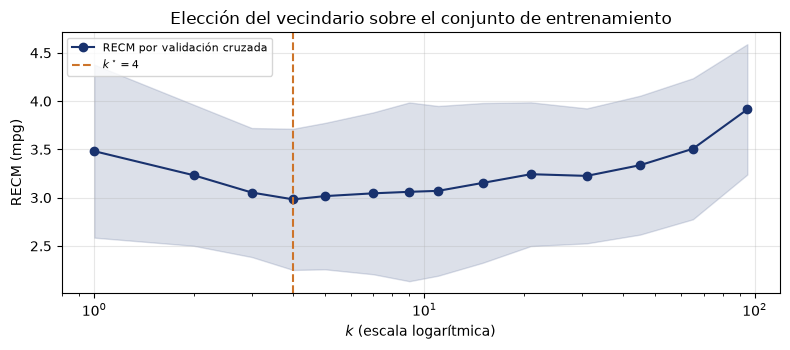

In [10]:
# VERIFICACIÓN — la búsqueda recorrió la rejilla y el escalador quedó dentro del pipeline
busqueda = buscar_k(X_ent, y_ent, REJILLA_K)
k_estrella = busqueda.best_params_["knn__n_neighbors"]

assert isinstance(busqueda.best_estimator_, Pipeline), "el estimador tiene que ser un Pipeline"
assert len(busqueda.cv_results_["mean_test_score"]) == len(REJILLA_K)

recm_vc = -busqueda.cv_results_["mean_test_score"]
de_vc = busqueda.cv_results_["std_test_score"]

print(f"{'k':>4}  {'RECM (VC)':>10}  {'DE':>7}")
for k, r, e in zip(REJILLA_K, recm_vc, de_vc):
    marca = "  <- mínimo" if k == k_estrella else ""
    print(f"{k:4d}  {r:10.4f}  {e:7.4f}{marca}")

print(f"\nk* = {k_estrella}")

fig, ax = plt.subplots()
ax.semilogx(REJILLA_K, recm_vc, "o-", color=AZUL, label="RECM por validación cruzada")
ax.fill_between(REJILLA_K, recm_vc - de_vc, recm_vc + de_vc, color=AZUL, alpha=0.15)
ax.axvline(k_estrella, color=NARANJA, ls="--", label=f"$k^\\star = {k_estrella}$")
ax.set_xlabel("$k$ (escala logarítmica)")
ax.set_ylabel("RECM (mpg)")
ax.set_title("Elección del vecindario sobre el conjunto de entrenamiento")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

---

# 3. La línea base lineal

Un resultado de k-NN no se interpreta solo. La comparación solo es informativa si el otro
modelo ve exactamente los mismos datos preparados de la misma manera, y por eso la línea
base se arma con **el mismo `ColumnTransformer`**: lo que quede de diferencia es atribuible
al método.

Se agrega una segunda referencia, más humilde y obligatoria: **la media del conjunto de
entrenamiento**, que es el modelo que ignora todos los atributos. Ningún modelo que no la
supere merece discusión.

### Ejercicio 3 — El modelo lineal de control

Corresponde armar el `Pipeline` de la regresión lineal, con la misma preparación que el
k-NN, y ajustarlo sobre el conjunto de entrenamiento.

In [11]:
def linea_base(X_ent: pd.DataFrame, y_ent: np.ndarray) -> Pipeline:
    modelo = Pipeline([
        ("prep", preparacion(X_ent)),
        ("lineal", LinearRegression()),
    ])
    return modelo.fit(X_ent, y_ent)

In [12]:
# VERIFICACIÓN — los dos modelos ven la misma matriz de atributos
lineal = linea_base(X_ent, y_ent)

cols_knn = busqueda.best_estimator_.named_steps["prep"].get_feature_names_out()
cols_lin = lineal.named_steps["prep"].get_feature_names_out()
assert list(cols_knn) == list(cols_lin), "los dos modelos no ven las mismas columnas"
print(f"los dos modelos ven las mismas {len(cols_lin)} columnas")


def medir(prediccion: np.ndarray, nombre: str) -> dict:
    """RECM, error absoluto medio y R^2 sobre el conjunto de prueba."""
    return {"modelo": nombre,
            "RECM": recm(y_pru, prediccion),
            "EAM": mean_absolute_error(y_pru, prediccion),
            "R2": r2_score(y_pru, prediccion)}


tabla = pd.DataFrame([
    medir(busqueda.best_estimator_.predict(X_pru), f"k-NN, k = {k_estrella}"),
    medir(lineal.predict(X_pru), "regresión lineal"),
    medir(np.full_like(y_pru, y_ent.mean()), "media de entrenamiento"),
]).set_index("modelo").round(4)

print("\nConjunto de prueba, sin tocar hasta acá (RECM y EAM en mpg):")
print(tabla.to_string())
print(f"\nk-NN reduce la RECM de la línea base en "
      f"{100 * (1 - tabla.loc[f'k-NN, k = {k_estrella}', 'RECM'] / tabla.loc['regresión lineal', 'RECM']):.1f} %")

los dos modelos ven las mismas 9 columnas

Conjunto de prueba, sin tocar hasta acá (RECM y EAM en mpg):
                          RECM     EAM      R2
modelo                                        
k-NN, k = 4             2.6298  1.9385  0.8629
regresión lineal        3.1949  2.4662  0.7976
media de entrenamiento  7.1696  5.9552 -0.0192

k-NN reduce la RECM de la línea base en 17.7 %


---

# 4. De dónde sale la diferencia

Que k-NN gane no explica por qué gana. La hipótesis es que la ventaja viene de **la
curvatura que el modelo lineal no puede representar**, y esa hipótesis se contrasta de dos
maneras.

La primera es directa: si el modelo lineal omite curvatura, sus residuos no están repartidos
al azar sino que **dependen sistemáticamente del valor ajustado**. La segunda es una prueba
por sustitución: se le agregan al modelo lineal los términos cuadráticos y los productos
cruzados, se lo vuelve a ajustar y se mira **cuánto de la diferencia desaparece**. Si
desaparece casi toda, la ventaja de k-NN era curvatura y nada más.

Residuos del modelo lineal, por cuartil del valor ajustado:
         mpg_ajustado_medio  residuo_medio   n
cuartil                                       
Q1                  13.6330         0.9345  74
Q2                  21.7367        -1.7244  73
Q3                  27.0414        -0.6098  73
Q4                  32.3765         1.3681  74


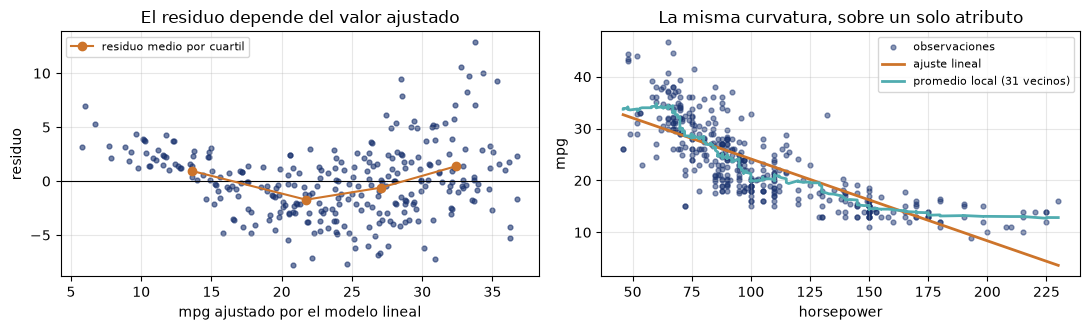

In [13]:
# Los residuos del modelo lineal contra el valor ajustado
ajustado = lineal.predict(X_ent)
residuo = y_ent - ajustado
cuartil = pd.qcut(ajustado, 4, labels=["Q1", "Q2", "Q3", "Q4"])

resumen = (pd.DataFrame({"ajustado": ajustado, "residuo": residuo, "cuartil": cuartil})
           .groupby("cuartil", observed=True)
           .agg(mpg_ajustado_medio=("ajustado", "mean"),
                residuo_medio=("residuo", "mean"),
                n=("residuo", "size"))
           .round(4))
print("Residuos del modelo lineal, por cuartil del valor ajustado:")
print(resumen.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].scatter(ajustado, residuo, s=12, c=AZUL, alpha=0.6)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].plot(resumen["mpg_ajustado_medio"], resumen["residuo_medio"], "o-",
             color=NARANJA, label="residuo medio por cuartil")
axes[0].set_xlabel("mpg ajustado por el modelo lineal")
axes[0].set_ylabel("residuo")
axes[0].set_title("El residuo depende del valor ajustado")
axes[0].legend(fontsize=8)

orden = np.argsort(auto["horsepower"].to_numpy())
hp = auto["horsepower"].to_numpy()[orden]
mpg = auto["mpg"].to_numpy()[orden]
recta = np.poly1d(np.polyfit(hp, mpg, 1))
axes[1].scatter(hp, mpg, s=12, c=AZUL, alpha=0.5, label="observaciones")
axes[1].plot(hp, recta(hp), color=NARANJA, lw=2, label="ajuste lineal")
axes[1].plot(hp, pd.Series(mpg).rolling(31, center=True, min_periods=8).mean(),
             color=TURQUESA, lw=2, label="promedio local (31 vecinos)")
axes[1].set_xlabel("horsepower"); axes[1].set_ylabel("mpg")
axes[1].set_title("La misma curvatura, sobre un solo atributo")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [14]:
# La prueba por sustitución: al modelo lineal se le agrega la curvatura que le falta
cuadratico = Pipeline([
    ("prep", preparacion(X_ent)),
    ("terminos", PolynomialFeatures(degree=2, include_bias=False)),
    ("lineal", LinearRegression()),
]).fit(X_ent, y_ent)

comparacion = pd.DataFrame([
    medir(busqueda.best_estimator_.predict(X_pru), f"k-NN, k = {k_estrella}"),
    medir(lineal.predict(X_pru), "lineal, solo términos de primer orden"),
    medir(cuadratico.predict(X_pru), "lineal, con términos cuadráticos y cruzados"),
]).set_index("modelo").round(4)

print("Conjunto de prueba:")
print(comparacion.to_string())

brecha = (comparacion.loc["lineal, solo términos de primer orden", "RECM"]
          - comparacion.loc[f"k-NN, k = {k_estrella}", "RECM"])
cerrada = (comparacion.loc["lineal, solo términos de primer orden", "RECM"]
           - comparacion.loc["lineal, con términos cuadráticos y cruzados", "RECM"])
print(f"\nbrecha entre el lineal de primer orden y k-NN : {brecha:.4f} mpg de RECM")
print(f"la que cierran los términos cuadráticos        : {cerrada:.4f} mpg "
      f"({100 * cerrada / brecha:.1f} % de la brecha)")

Conjunto de prueba:
                                               RECM     EAM      R2
modelo                                                             
k-NN, k = 4                                  2.6298  1.9385  0.8629
lineal, solo términos de primer orden        3.1949  2.4662  0.7976
lineal, con términos cuadráticos y cruzados  2.7263  1.9263  0.8526

brecha entre el lineal de primer orden y k-NN : 0.5651 mpg de RECM
la que cierran los términos cuadráticos        : 0.4686 mpg (82.9 % de la brecha)


In [15]:
# El escalado, en el mismo problema: k-NN con los atributos numéricos sin estandarizar
sin_escalar = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", list(X_ent.select_dtypes("number").columns)),
        ("cat", OneHotEncoder(sparse_output=False), ["origin"])])),
    ("knn", KNeighborsRegressor(n_neighbors=k_estrella)),
]).fit(X_ent, y_ent)

con = recm(y_pru, busqueda.best_estimator_.predict(X_pru))
sin = recm(y_pru, sin_escalar.predict(X_pru))
print(f"k-NN con estandarización : RECM {con:.4f} mpg")
print(f"k-NN sin estandarización : RECM {sin:.4f} mpg   (un {100 * (sin / con - 1):.1f} % peor)")

aportes = 2 * X_ent.select_dtypes("number").to_numpy(dtype=float).var(axis=0)
nombres_num = X_ent.select_dtypes("number").columns.to_numpy()
orden_ap = np.argsort(aportes)[::-1]
print("\nsin estandarizar, el aporte de cada atributo a E[d^2] es:")
for j in orden_ap:
    print(f"  {nombres_num[j]:16s} {aportes[j]:14.4f}  "
          f"({100 * aportes[j] / aportes.sum():6.3f} % del total)")

k-NN con estandarización : RECM 2.6298 mpg
k-NN sin estandarización : RECM 4.3328 mpg   (un 64.8 % peor)

sin estandarizar, el aporte de cada atributo a E[d^2] es:
  weight             1412337.4251  (98.271 % del total)
  displacement         21831.4110  ( 1.519 % del total)
  horsepower            2969.8182  ( 0.207 % del total)
  year                    26.5752  ( 0.002 % del total)
  acceleration            16.2694  ( 0.001 % del total)
  cylinders                5.8451  ( 0.000 % del total)


### Para analizar

1. El $k$ elegido por validación cruzada es de un dígito, y el error crece con claridad a
   partir de ahí. **¿Qué dice ese valor sobre la forma de la superficie que se está
   estimando?** Conviene contrastarlo con el $k$ de la práctica de clasificación sobre el
   conjunto de riesgo crediticio, donde la validación cruzada eligió cientos de vecinos.
2. Los términos cuadráticos cierran buena parte de la brecha entre el modelo lineal y k-NN.
   **¿Qué queda sin cerrar, y qué habría que agregarle al modelo lineal para cerrarlo?**
3. El modelo lineal produce coeficientes interpretables y una predicción en tiempo
   constante; k-NN requiere conservar las $294$ observaciones y recorrerlas en cada
   consulta. **Con la diferencia de error medida arriba, ¿cuál de los dos corresponde poner
   en producción?** La respuesta tiene que fijar bajo qué condición cambia.
4. El conjunto tiene $392$ observaciones y $9$ columnas después de codificar.
   **¿Qué pasaría con la ventaja de k-NN si se agregaran veinte atributos más, informativos
   o no?** El experimento del laboratorio de la clase responde la mitad de esta pregunta.

**Respuesta:**

1. El $k=4$ elegido indica una superficie con curvatura local: promediar demasiados
   vecinos borra estructura útil. En riesgo crediticio se eligió $k=101$ porque la
   frontera era mucho más suave y aproximadamente lineal.
2. Los términos de grado dos cierran el $82.9\%$ de la brecha. Quedan curvaturas de
   orden superior, interacciones más complejas y posibles cambios locales. Podrían
   agregarse términos cúbicos, splines o transformaciones guiadas por los residuos,
   controlando el sobreajuste mediante validación cruzada.
3. k-NN reduce la RECM de $3.1949$ a $2.6298$ mpg, un $17.7\%$. Lo pondría en
   producción si esa mejora tiene valor operativo y la latencia de recorrer 294
   observaciones es aceptable; elegiría el lineal si importan más la explicación y
   la velocidad, o si la mejora no se sostiene en validación externa.
4. Veinte columnas de ruido diluirían la señal y volverían menos fiables los
   vecindarios. Atributos informativos podrían ayudar, pero con solo 392 casos
   también agrandan el espacio y exigen muchas más observaciones. Por eso la ventaja
   de k-NN probablemente se reduciría salvo que las variables nuevas aportaran señal
   fuerte y se hiciera selección o reducción de dimensión.


---

# Conclusión

**El entregable de esta práctica es esta conclusión.** Corresponde escribir tres o cuatro
líneas que respondan, con las cifras producidas arriba, a las dos preguntas con las que abre
el notebook: cuánto gana un método local cuando el modelo lineal está mal especificado, y de
dónde sale exactamente lo que gana.

**Conclusión:** 

k-NN con $k=4$ obtiene RECM $2.6298$ mpg, frente a $3.1949$ de la
regresión lineal, una reducción del $17.7\%$. Los términos cuadráticos bajan la RECM
a $2.7263$ y cierran el $82.9\%$ de la brecha, por lo que la ventaja de k-NN proviene
principalmente de representar curvatura. La elección productiva depende de si esa
mejora justifica perder interpretabilidad y velocidad de predicción.

## Para seguir explorando

Fuera del tiempo de clase, y sin evaluación:

1. **La ponderación por distancia.** `KNeighborsRegressor(weights="distance")` pondera cada
   vecino por $1/d$. Repetir la búsqueda de $k$ con esa variante y medir si el $k^\star$ se
   mueve y si el error de prueba mejora.
2. **`cylinders` como categórico.** Rehacer la preparación tratando `cylinders` con
   indicadoras y medir el efecto sobre el error de validación cruzada. La respuesta al
   `DECIDE` de la sección 1 queda así contrastada contra una medición.
3. **La estructura temporal.** `year` va de $70$ a $82$ y la eficiencia mejora a lo largo
   del período. Partir por año en lugar de al azar —entrenar con los modelos hasta $79$ y
   predecir los de $80$ a $82$— y comparar el error contra el de la partición aleatoria. La
   diferencia entre las dos cifras es una forma de fuga de información.